In [58]:
suppressMessages({library(rwwa); library(quantreg); library(mev)})
png_res <- 240

# Quantile regression

In [ ]:
gmst <- read.table("data/gmst.dat", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == 2026]

df <- merge(read.csv("data/tasmax_impact_daily_ts_ERA5-Land.csv", row.names = "X"), read.csv("data/tasmin_impact_daily_ts_ERA5-Land.csv", row.names = "X"))

df$year <- substr(df$time,1,4)
df$month <- substr(df$time,6,7)

df <- merge(gmst, df)
# df <- df[df$month %in% c(12,1,2),]

In [62]:
qq <- c(0.005,0.01,0.025,0.05,0.1,0.15,0.25,0.5,0.75,0.85,0.9,0.95,0.975,0.99,0.995)
qr_tmax <- rq(tasmax ~ gmst, data = df, tau = qq)
qpred_tmax <- fitted(qr_tmax) #  get fitted quantiles

qr_tmin <- rq(tasmin ~ gmst, data = df, tau = qq)
qpred_tmin <- fitted(qr_tmin) #  get fitted quantiles

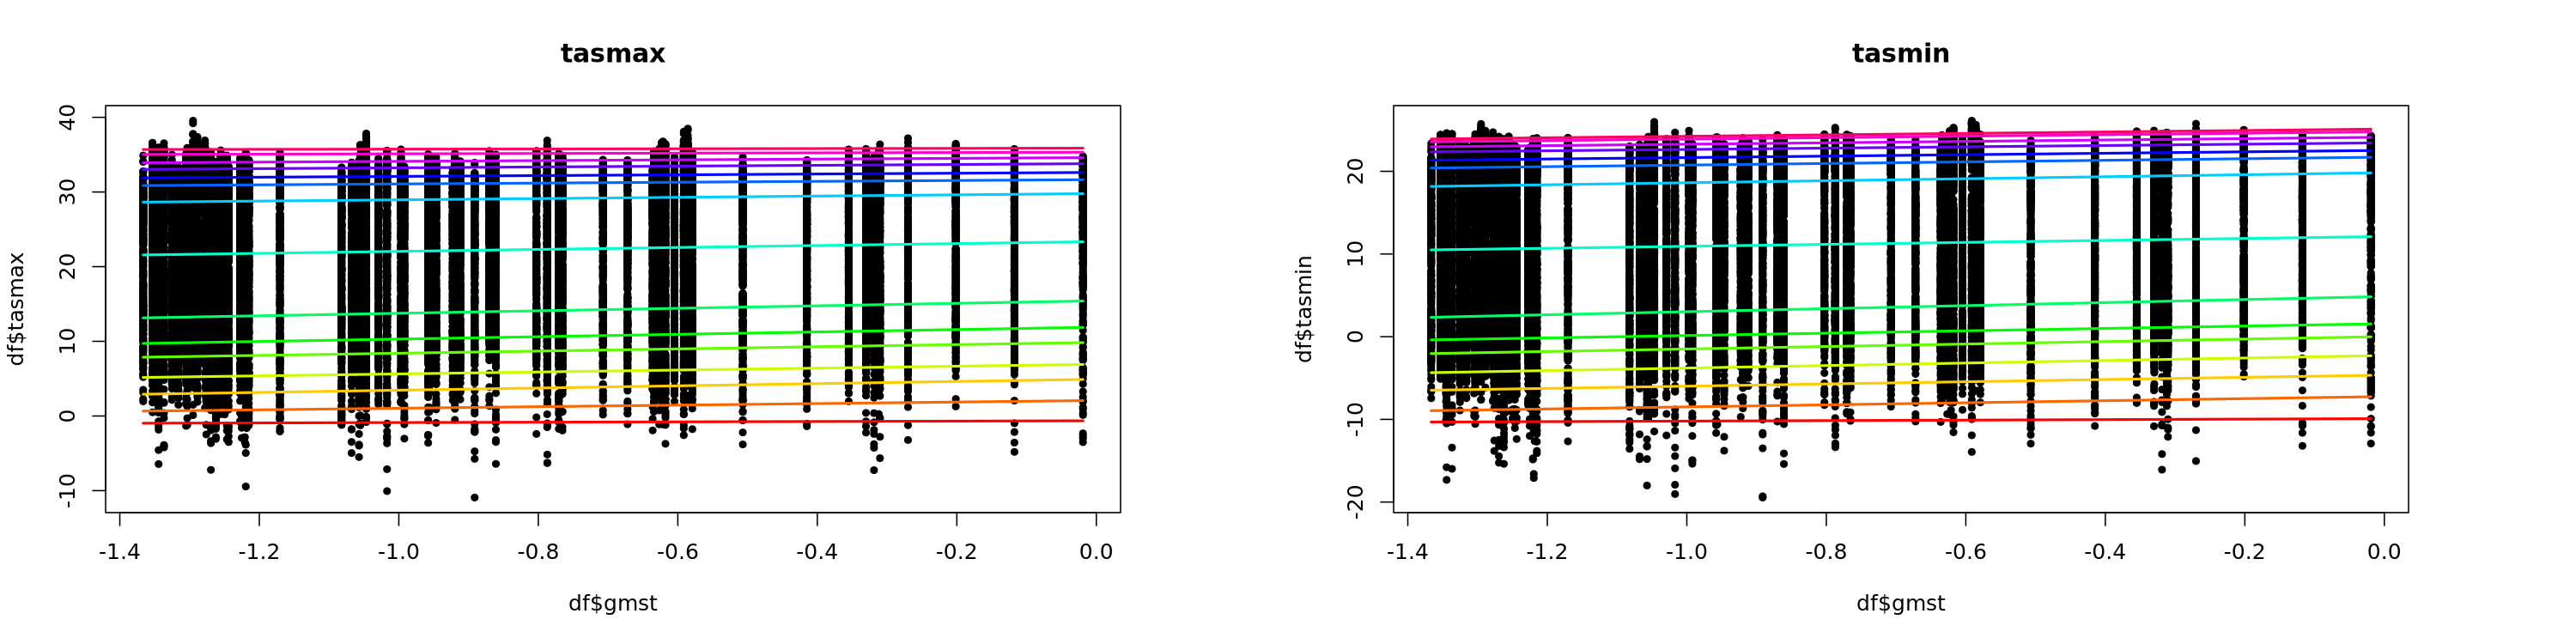

In [63]:
prep_window(c(1,2), xpd=TRUE, mar = c(5.1, 4.1, 4.1, 6.5), res = 150, h = 5, w = 10)
plot(df$gmst, df$tasmax, main = paste0("tasmax"))
matplot(df$gmst, qpred_tmax, add = T, type = "l", lty = 1, lwd = 2, col = rainbow(length(qq)))
# legend("right", inset = c(-0.22, 0), legend = qq, lty = 1, col = rainbow(length(qq)), bty = "n")

plot(df$gmst, df$tasmin, main = paste0("tasmin"))
matplot(df$gmst, qpred_tmin, add = T, type = "l", lty = 1, lwd = 2, col = rainbow(length(qq)))

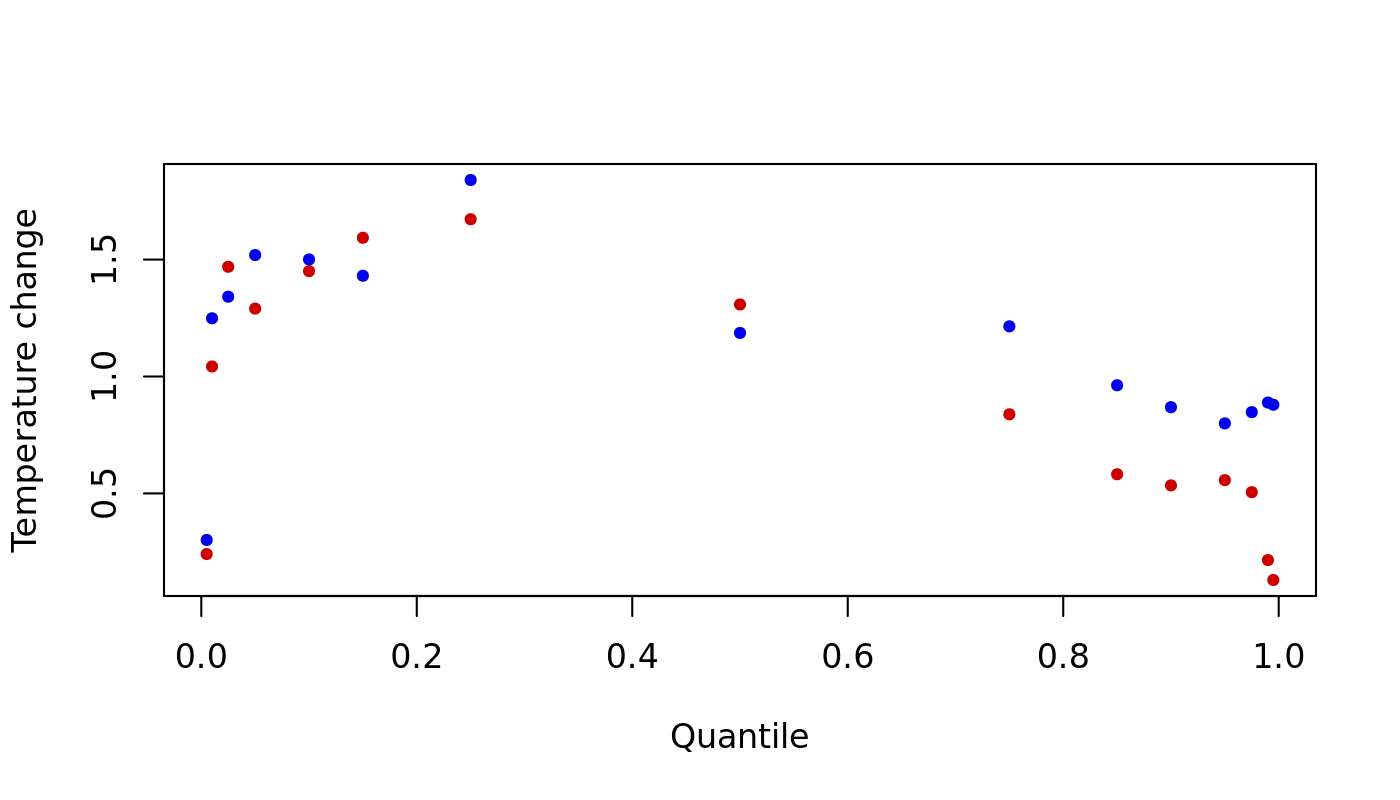

In [64]:
prep_window(w = 7)
matplot(qq, t(rbind("tmax" = coef(qr_tmax)["gmst",], "tmin" = coef(qr_tmin)["gmst",])), pch = 20, ylab = "Temperature change", col = c("red3", "blue2"), xlab = "Quantile")

# Joint change in temperature & precip

In [41]:
rnm <- "impact"
df <- merge(read.csv(paste0("data/pr_",rnm,"_daily_ts_ERA5-Land.csv")), read.csv(paste0("data/tasmax_",rnm,"_daily_ts_ERA5-Land.csv")))

df$pr <- (df$pr + 273.15) * 86400
df$year <- as.integer(substr(df$time,1,4))
df$month <- as.integer(substr(df$time,6,7))

gmst <- read.table("data/gmst.dat", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == 2026]

df <- merge(gmst, df)
df <- df[df$month %in% c(12,1,2),]

df <- df[df$pr > 0,]

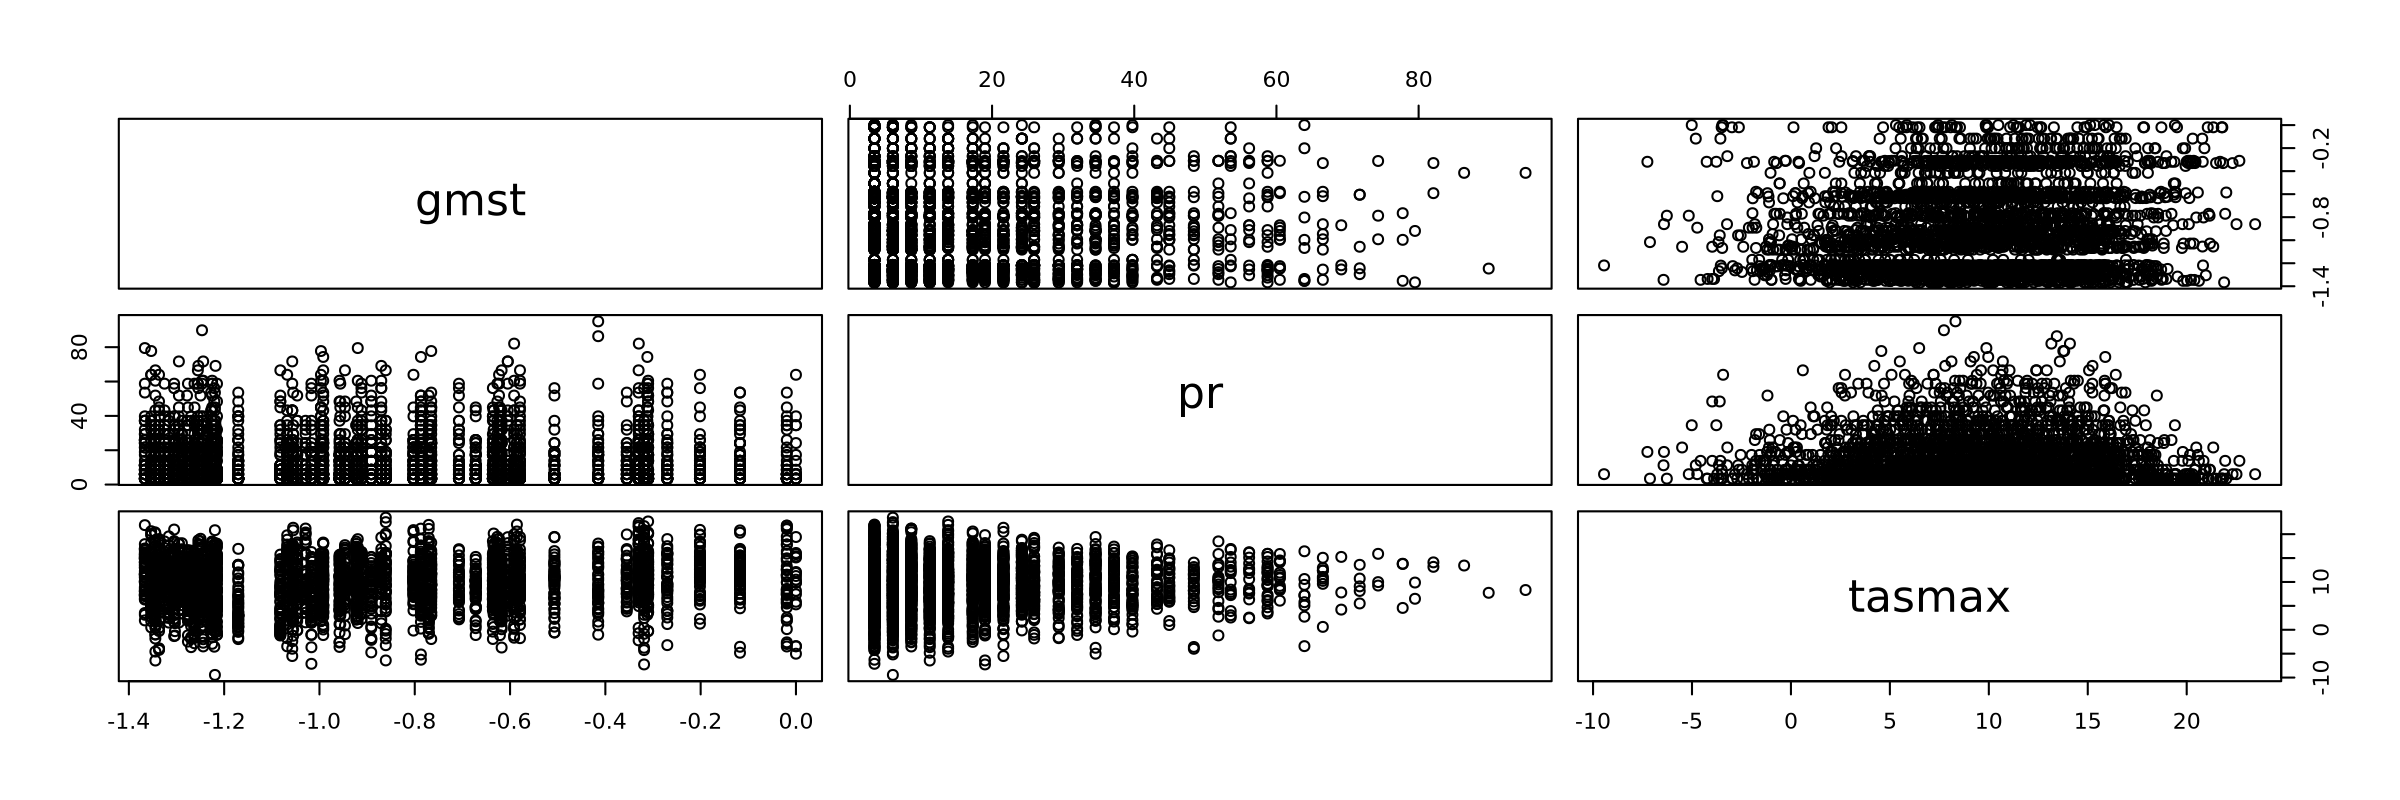

In [42]:
prep_window()
pairs(df[,c("gmst", "pr", "tasmax")])

## Marginal distributions

In [ ]:
pr_segp = egp.fit(df$pr[df$pr > 0], model = "egp1", thresh = 0) # extended GP estimate

In [104]:
dextgp(x, type = 1, kappa = pr_segp$est["kappa"], sigma = pr_segp$est["scale"], xi = pr_segp$est["shape"])

[1] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  [6] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [11] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [16] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [21] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [26] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [31] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [36] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [41] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [46] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [51] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [56] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [61] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [66] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [71] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [76] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [81] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [86] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [91] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [96] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
[101] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
[106] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
[111] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
[116] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
[121] 0.000000e+00 3.351451e-17 2.934413e-08 5.278364e-05 1.944711e-03
[126] 1.422631e-02 4.672587e-02 9.855862e-02 1.596021e-01 2.187417e-01
[131] 2.686065e-01 3.060784e-01 3.310319e-01 3.449341e-01 3.498511e-01
[136] 3.478805e-01 3.408841e-01 3.303965e-01 3.176249e-01 3.034869e-01
[141] 2.886621e-01 2.736412e-01 2.587698e-01 2.442837e-01 2.303378e-01
[146] 2.170271e-01 2.044036e-01 1.924887e-01 1.812825e-01 1.707704e-01
[151] 1.609281e-01 1.517253e-01 1.431283e-01 1.351016e-01 1.276096e-01
[156] 1.206171e-01 1.140900e-01 1.079958e-01 1.023037e-01 9.698471e-02
[161] 9.201173e-02 8.735952e-02 8.300465e-02 7.892537e-02 7.510160e-02
[166] 7.151478e-02 6.814777e-02 6.498479e-02 6.201126e-02 5.921376e-02
[171] 5.657991e-02 5.409831e-02 5.175844e-02 4.955060e-02 4.746584e-02
[176] 4.549589e-02 4.363312e-02 4.187047e-02 4.020144e-02 3.861997e-02
[181] 3.712050e-02 3.569783e-02 3.434718e-02 3.306409e-02 3.184443e-02
[186] 3.068437e-02 2.958033e-02 2.852901e-02 2.752730e-02 2.657233e-02
[191] 2.566142e-02 2.479207e-02 2.396193e-02 2.316884e-02 2.241075e-02
[196] 2.168575e-02 2.099207e-02 2.032802e-02 1.969204e-02 1.908266e-02
[201] 1.849851e-02 1.793829e-02 1.740079e-02 1.688486e-02 1.638943e-02
[206] 1.591349e-02 1.545608e-02 1.501632e-02 1.459335e-02 1.418637e-02
[211] 1.379464e-02 1.341744e-02 1.305410e-02 1.270399e-02 1.236651e-02
[216] 1.204109e-02 1.172719e-02 1.142431e-02 1.113196e-02 1.084968e-02
[221] 1.057705e-02 1.031365e-02 1.005908e-02 9.812994e-03 9.575021e-03
[226] 9.344832e-03 9.122108e-03 8.906547e-03 8.697861e-03 8.495775e-03
[231] 8.300029e-03 8.110373e-03 7.926571e-03 7.748396e-03 7.575633e-03
[236] 7.408075e-03 7.245527e-03 7.087801e-03 6.934717e-03 6.786105e-03
[241] 6.641801e-03 6.501647e-03 6.365496e-03 6.233202e-03 6.104630e-03
[246] 5.979648e-03 5.858129e-03 5.739955e-03 5.625009e-03 5.513180e-03
[251] 5.404363e-03 5.298455e-03 5.195360e-03 5.094983e-03 4.997234e-03
[256] 4.902027e-03 4.809279e-03 4.718909e-03 4.630843e-03 4.545005e-03
[261] 4.461324e-03 4.379734e-03 4.300167e-03 4.222562e-03 4.146856e-03
[266] 4.072993e-03 4.000914e-03 3.930567e-03 3.861899e-03 3.794859e-03
[271] 3.729399e-03 3.665472e-03 3.603032e-03 3.542037e-03 3.482445e-03
[276] 3.424214e-03 3.367305e-03 3.311681e-03 3.257306e-03 3.204143e-03
[281] 3.152160e-03 3.10132

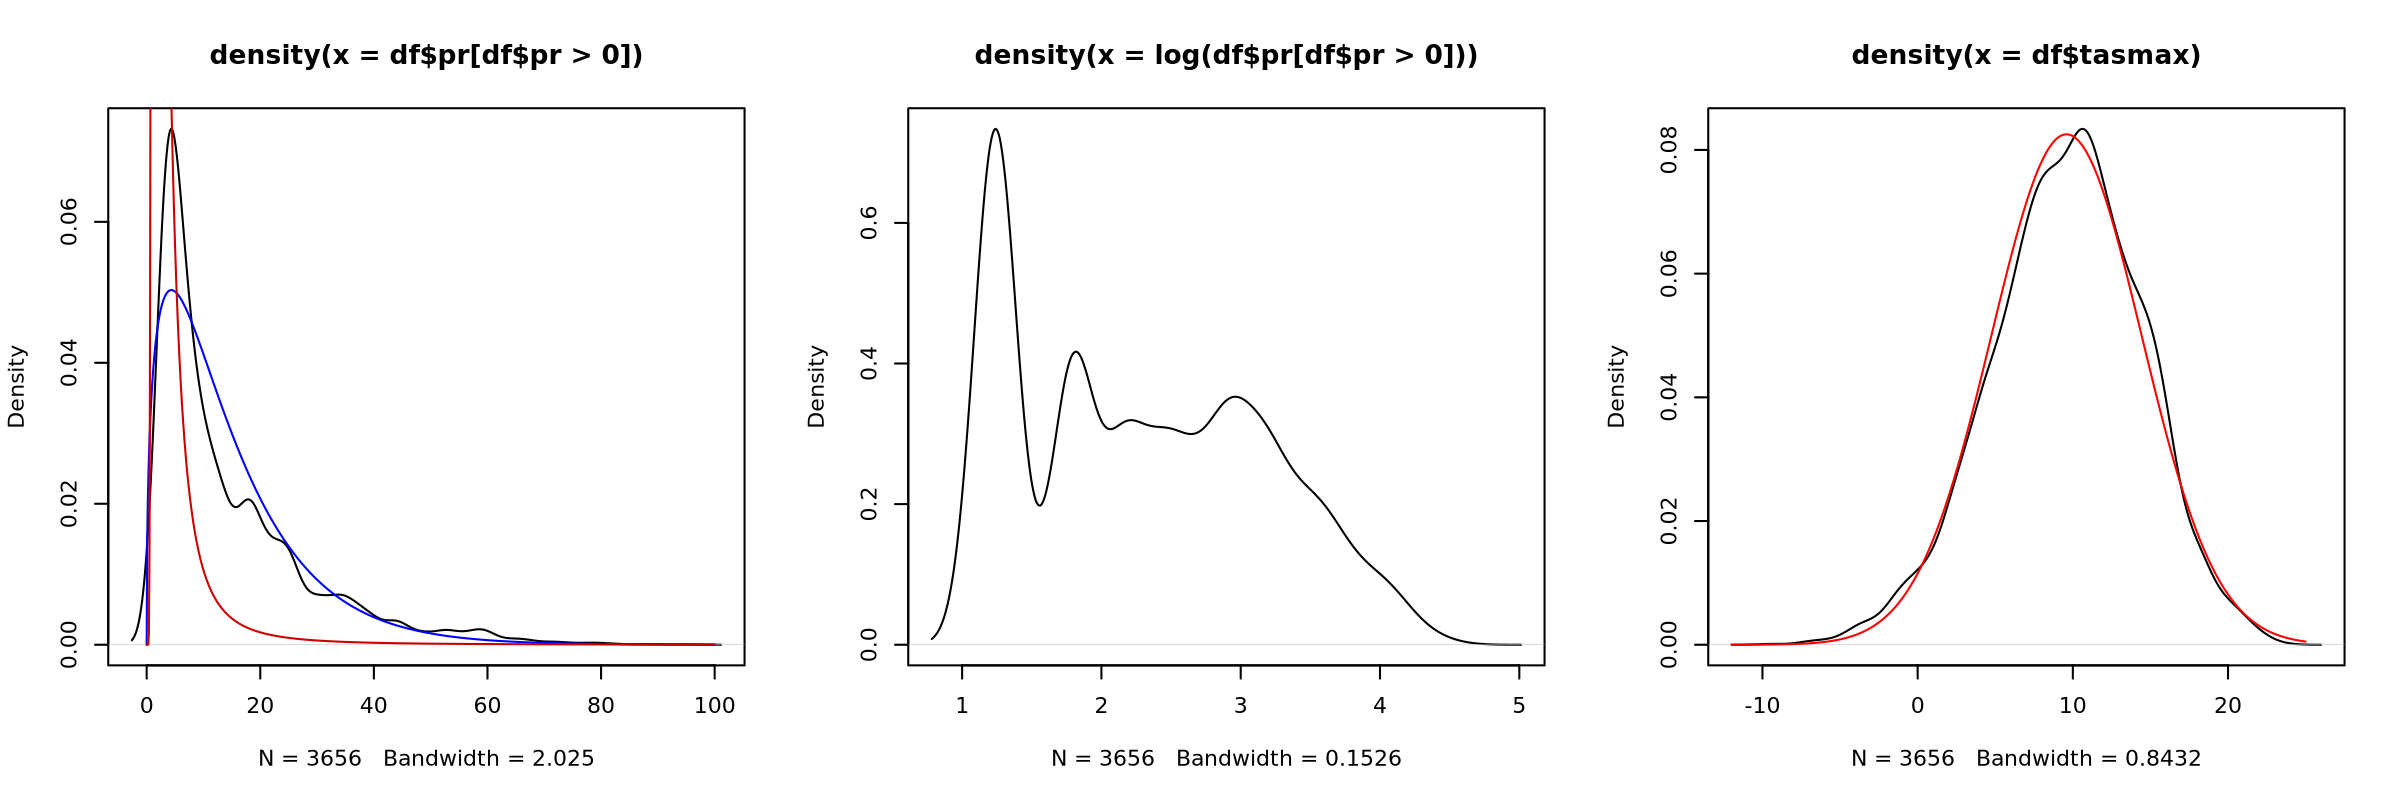

In [105]:
prep_window(c(1,3))

plot(density(df$pr[df$pr > 0]))
par_gamma <- fitdistr(df$pr[df$pr > 0], "gamma")
lines(x <- seq(0,100, 0.1), dgamma(x, shape = par_gamma$estimate["shape"], rate = par_gamma$estimate["rate"]), col = "blue")
lines(x <- seq(0,100, 0.1), dextgp(x, type = 1, kappa = pr_segp$est["kappa"], sigma = pr_segp$est["scale"], xi = pr_segp$est["shape"]), col = "red3")

plot(density(log(df$pr[df$pr > 0])))

plot(density(df$tasmax))
lines(x <- seq(-12,25, 0.1), dnorm(x, mean(df$tasmax), sd(df$tasmax)), col = "red")

In [70]:
gp.fit(df$pr, 0)$est

scale       shape 
15.24296162 -0.04962474

kappa       scale       shape 
76.19053050  0.09387642  0.59278344

In [ ]:
z <- fit.extgp(rain[rain>0], model = 1, method = 'mle', init = c(0.9, gp.fit(rain, 0)$est), rounded = 0.1, confint = TRUE, R = 20)